In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report,accuracy_score


In [2]:
df=pd.read_csv("./data.csv")

In [3]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [5]:
df.isna().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [6]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [7]:
df.dtypes

id                        int64
Gender                   object
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age              object
Vehicle_Damage           object
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [8]:
df['Driving_License'].value_counts()

Driving_License
1    380297
0       812
Name: count, dtype: int64

In [49]:
df.shape

(381109, 12)

In [50]:
df['Annual_Premium'].describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

<Axes: >

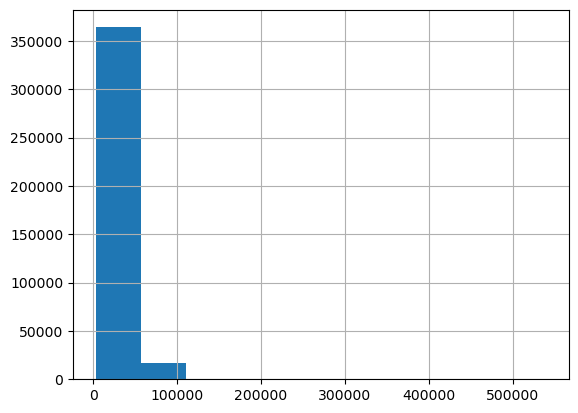

In [51]:
df['Annual_Premium'].hist(bins=10)

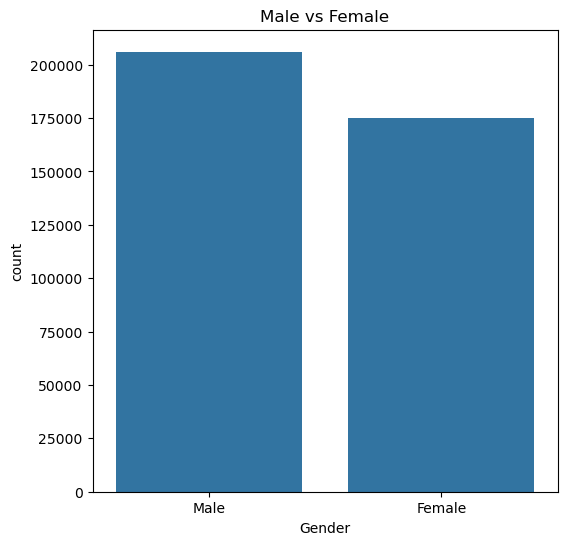

In [10]:
plt.figure(figsize=(6,6))
sns.barplot(df['Gender'].value_counts())
plt.title('Male vs Female')
plt.show()

In [11]:
df['Vehicle_Age'].unique()

array(['> 2 Years', '1-2 Year', '< 1 Year'], dtype=object)

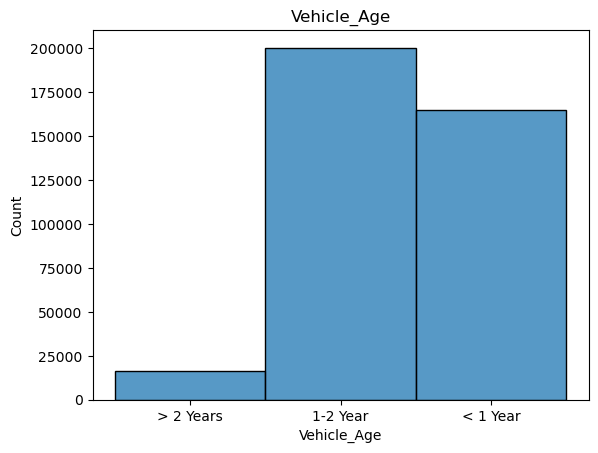

In [12]:
sns.histplot(df['Vehicle_Age'])
plt.title('Vehicle_Age')
plt.show()

In [14]:
veh_age_percen=(list(df['Vehicle_Age'].value_counts())/df['Vehicle_Age'].count())*100

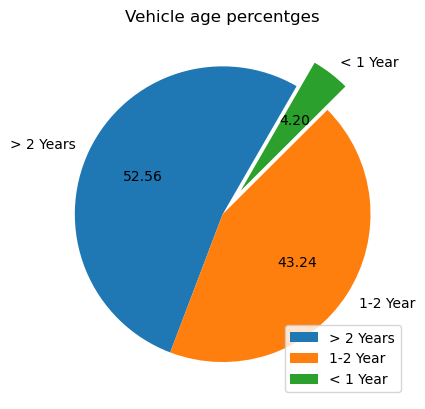

In [15]:
plt.pie(veh_age_percen,startangle=60,labels=df['Vehicle_Age'].unique(),autopct='%.2f',explode=[0,0,0.2])
plt.legend()
plt.title('Vehicle age percentges')
plt.show()

In [16]:
df['Region_Code'].unique()

array([28.,  3., 11., 41., 33.,  6., 35., 50., 15., 45.,  8., 36., 30.,
       26., 16., 47., 48., 19., 39., 23., 37.,  5., 17.,  2.,  7., 29.,
       46., 27., 25., 13., 18., 20., 49., 22., 44.,  0.,  9., 31., 12.,
       34., 21., 10., 14., 38., 24., 40., 43., 32.,  4., 51., 42.,  1.,
       52.])

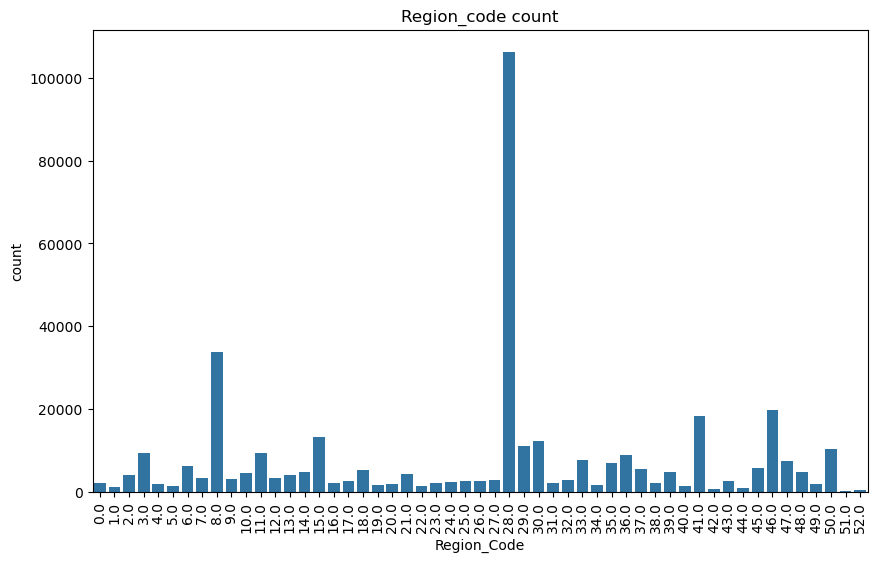

In [17]:

plt.figure(figsize=(10,6))
sns.barplot(df['Region_Code'].value_counts())
plt.title('Region_code count')
plt.xticks(rotation=90)
plt.show()

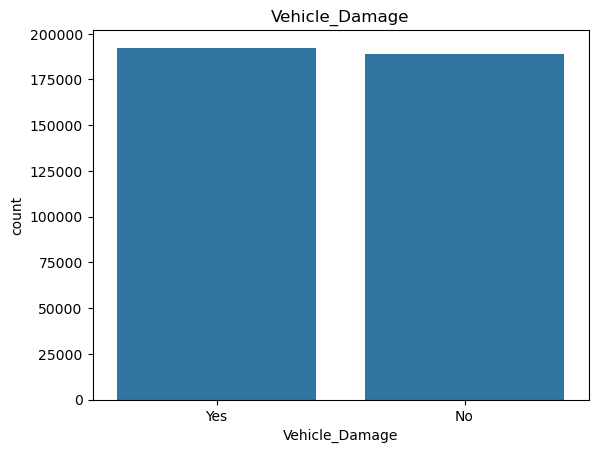

In [47]:
sns.barplot(df['Vehicle_Damage'].value_counts())
plt.title('Vehicle_Damage')
plt.show()

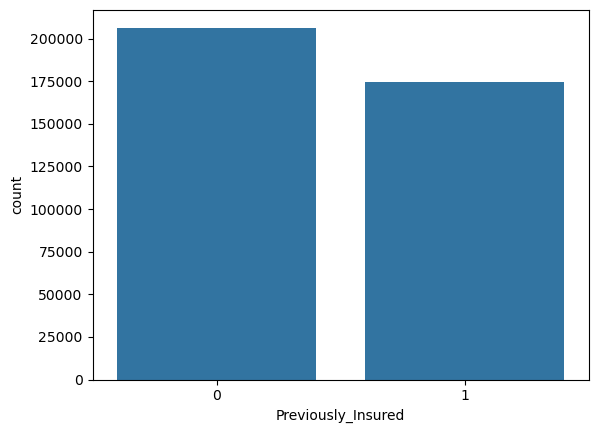

In [19]:
sns.barplot(df['Previously_Insured'].value_counts())
plt.show()


In [8]:
response_counts=df['Response'].value_counts()

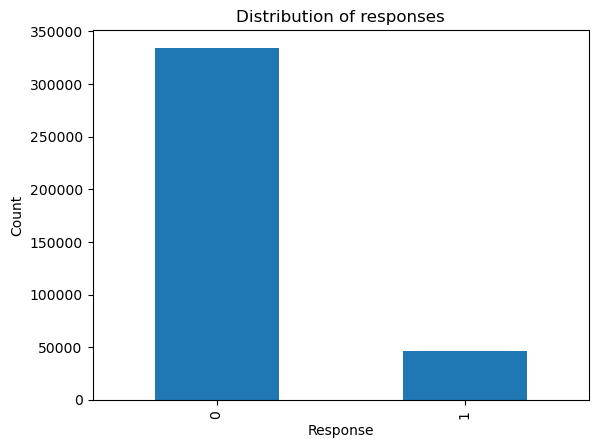

In [9]:
response_counts.plot(kind="bar")
plt.xlabel('Response')
plt.ylabel('Count')
plt.title('Distribution of responses')
plt.show()

<Axes: >

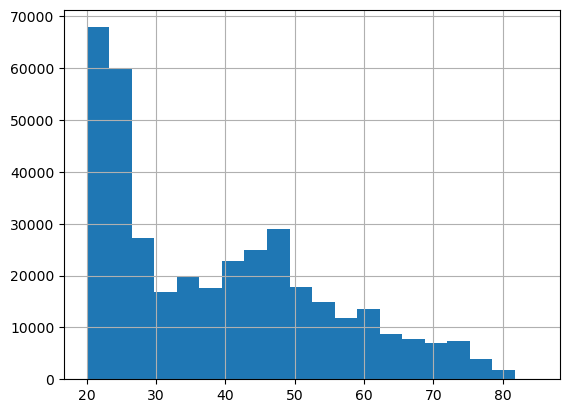

In [12]:
df['Age'].hist(bins=20)

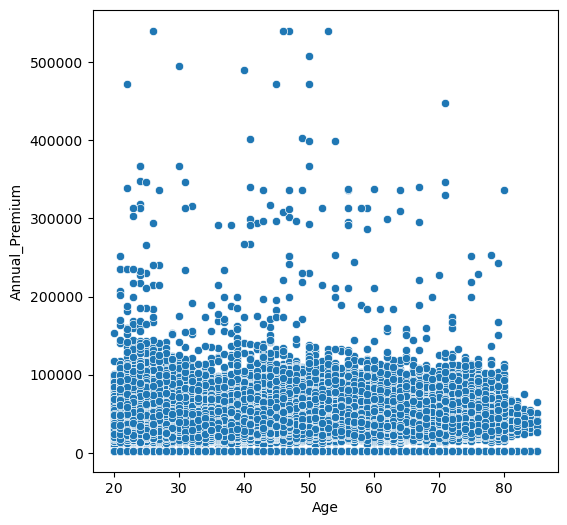

In [13]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='Age',y='Annual_Premium',data=df)
plt.xlabel('Age')
plt.ylabel('Annual_Premium')
plt.show()

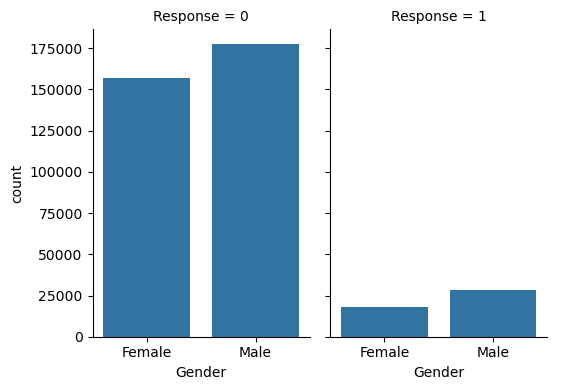

In [39]:
data=df.groupby(['Gender','Response'])['id'].count().to_frame()
data=data.rename(columns={'id':'count'})
sns.catplot(x="Gender",y="count",col='Response',data=data,kind="bar",height=4,aspect=.7)

In [31]:
data

id
Gender Response        
Female 0         156835
       1          18185
Male   0         177564
       1          28525

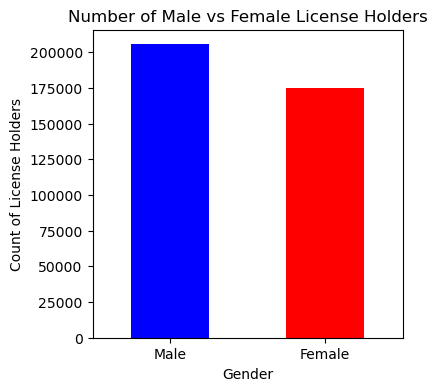

In [41]:
license_holders = df[df['Driving_License'] == 1]

gender_counts = license_holders['Gender'].value_counts()


plt.figure(figsize=(4, 4))
gender_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Number of Male vs Female License Holders')
plt.xlabel('Gender')
plt.ylabel('Count of License Holders')
plt.xticks(rotation=0)
plt.show()


In [44]:
data=df.groupby(['Vehicle_Age','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
data

,Vehicle_Age,Response,count
0,1-2 Year,0,165510
1,1-2 Year,1,34806
2,< 1 Year,0,157584
3,< 1 Year,1,7202
4,> 2 Years,0,11305
5,> 2 Years,1,4702


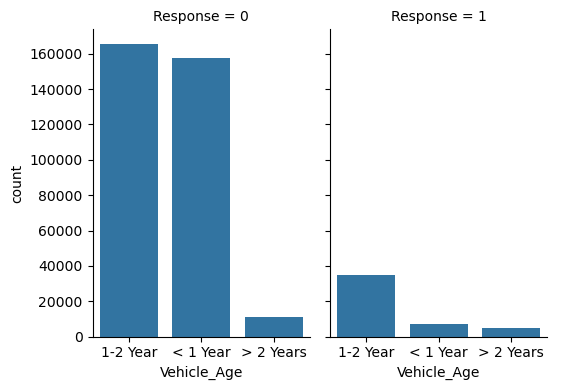

In [46]:
sns.catplot(x="Vehicle_Age", y="count",col="Response",
                data=data, kind="bar",
                height=4, aspect=.7);

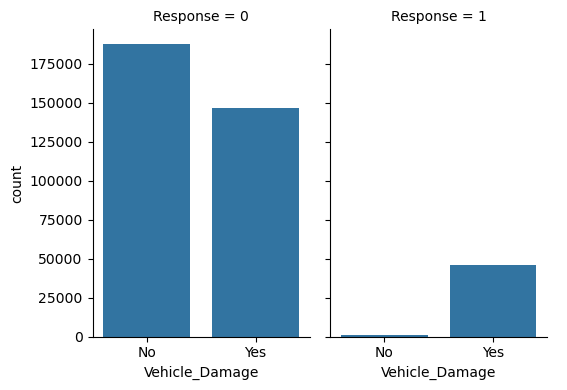

In [48]:
data = df.groupby(['Vehicle_Damage','Response'])['id'].count().to_frame().rename(columns={'id':'count'}).reset_index()
g = sns.catplot(x="Vehicle_Damage", y="count",col="Response", data=data, kind="bar", height=4, aspect=.7);

DATA PREPROCESSING

In [52]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [67]:
num_feat=['Age','Vintage']
cat_feat=['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age_lt_1_Year',
'Vehicle_Age_gt_2_Years','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [68]:
df['Gender']=df['Gender'].map({'Female':0,'Male':1}).astype(int)

In [69]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [71]:
df=pd.get_dummies(df,drop_first=True)
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False
2,3,1,47,1,28.0,0,38294.0,26.0,27,1,False,True,True
3,4,1,21,1,11.0,1,28619.0,152.0,203,0,True,False,False
4,5,0,29,1,41.0,1,27496.0,152.0,39,0,True,False,False


In [72]:
df = df.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})
df['Vehicle_Age_lt_1_Year'] = df['Vehicle_Age_lt_1_Year'].astype('int')
df['Vehicle_Age_gt_2_Years'] = df['Vehicle_Age_gt_2_Years'].astype('int')
df['Vehicle_Damage_Yes'] = df['Vehicle_Damage_Yes'].astype('int')

for column in cat_feat:
    df[column] = df[column].astype('str')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      381109 non-null  int64  
 1   Gender                  381109 non-null  object 
 2   Age                     381109 non-null  int64  
 3   Driving_License         381109 non-null  object 
 4   Region_Code             381109 non-null  object 
 5   Previously_Insured      381109 non-null  object 
 6   Annual_Premium          381109 non-null  float64
 7   Policy_Sales_Channel    381109 non-null  object 
 8   Vintage                 381109 non-null  int64  
 9   Response                381109 non-null  int64  
 10  Vehicle_Age_lt_1_Year   381109 non-null  object 
 11  Vehicle_Age_gt_2_Years  381109 non-null  object 
 12  Vehicle_Damage_Yes      381109 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 37.8+ MB


In [75]:
std=StandardScaler()
df[num_feat]=std.fit_transform(df[num_feat])

mm=MinMaxScaler()
df[['Annual_Premium']]=mm.fit_transform(df[['Annual_Premium']])

id=df['id']
df=df.drop('id',axis=1)

In [76]:
df[num_feat]

,Age,Vintage
0,0.333777,0.748795
1,2.396751,0.342443
2,0.527181,-1.521998
3,-1.148985,0.581474
4,-0.633242,-1.378580
...,...,...
381104,2.267815,-0.792954
381105,-0.568774,-0.279037
381106,-1.148985,0.079509
381107,1.881007,-0.960275


In [77]:
df['Annual_Premium']

0         0.070366
1         0.057496
2         0.066347
3         0.048348
4         0.046259
            ...   
381104    0.051234
381105    0.069551
381106    0.060439
381107    0.078110
381108    0.072827
Name: Annual_Premium, Length: 381109, dtype: float64

In [87]:
x=df.drop(['Response'],axis=1)
y=df['Response']


In [88]:
x

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Years,Vehicle_Damage_Yes
0,1,0.333777,1,28.0,0,0.070366,26.0,0.748795,0,1,1
1,1,2.396751,1,3.0,0,0.057496,26.0,0.342443,0,0,0
2,1,0.527181,1,28.0,0,0.066347,26.0,-1.521998,0,1,1
3,1,-1.148985,1,11.0,1,0.048348,152.0,0.581474,1,0,0
4,0,-0.633242,1,41.0,1,0.046259,152.0,-1.378580,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
381104,1,2.267815,1,26.0,1,0.051234,26.0,-0.792954,0,0,0
381105,1,-0.568774,1,37.0,1,0.069551,152.0,-0.279037,1,0,0
381106,1,-1.148985,1,30.0,1,0.060439,160.0,0.079509,1,0,0
381107,0,1.881007,1,14.0,0,0.078110,124.0,-0.960275,0,1,1


In [89]:
y

0         1
1         0
2         1
3         0
4         0
         ..
381104    0
381105    0
381106    0
381107    0
381108    0
Name: Response, Length: 381109, dtype: int64

In [90]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)

In [97]:
random_search={ 'criterion': ['entropy'],
               'max_depth': [2,3,4,5,6,7,10],
               'min_samples_leaf': [4, 6, 8],
               'min_samples_split': [5, 7,10],
               'n_estimators': [300]
              }

clf=RandomForestClassifier()
model=RandomizedSearchCV(estimator=clf,param_distributions=random_search,n_iter=10,cv=4,verbose=1,random_state=101,n_jobs=-1)
model.fit(x_train,y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


RandomizedSearchCV(cv=4, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['entropy'],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 10],
                                        'min_samples_leaf': [4, 6, 8],
                                        'min_samples_split': [5, 7, 10],
                                        'n_estimators': [300]},
                   random_state=101, verbose=1)

In [98]:
model.best_params_

{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_depth': 10,
 'criterion': 'entropy'}

In [99]:

import pickle

filename = 'rf_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [101]:
rf_load = pickle.load(open(filename, 'rb'))

In [102]:
y_pred=model.predict(x_test)
print (classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      1.00      0.93     83513
           1       0.00      0.00      0.00     11765

    accuracy                           0.88     95278
   macro avg       0.44      0.50      0.47     95278
weighted avg       0.77      0.88      0.82     95278



In [105]:
acc=accuracy_score(y_test,y_pred)

In [106]:
acc

0.8765087428367514